# CNG Auto-Rickshaw Stand Placement Optimization Using AHP & GA - Sylhet (Temuki–Bondor Point Corridor)

**Project question:** Are the current CNG stand locations (Modina Market, Pathantula, 
Rikabi Bazar) optimally placed, or would different locations along the corridor 
score better under the AHP-weighted criteria? Temuki and Bondor Bazar are treated 
as fixed route termini. The Genetic Algorithm searches the full set of candidate 
points along the corridor (not limited to the 5 existing stands) meaning its 
output may either confirm an existing stand's location as near-optimal, or suggest 
an entirely new, better-scoring location nearby.

**Corridor:** Temuki to Bondor Bazar, Sylhet  
**Fixed endpoints:** Temuki, Bondor Bazar (route termini, not subject to relocation)  
**Flexible stands (open to re-evaluation):** Modina Market, Pathantula, Rikabi Bazar

**Data:** Real GPS coordinates (Google Maps) for 9 landmarks, 5 corridor path points, 
and 5 existing CNG stand locations.

# Model Set Up and Data Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import math

plt.rcParams['figure.figsize'] = (10, 6)
random.seed(42)
np.random.seed(42)

In [2]:
landmarks = pd.read_csv('Land Marks.csv')
corridor_points = pd.read_csv('Intermediate Point.csv')
existing_stands = pd.read_csv('CNG_Stand_Location.csv')

print("Landmarks:", landmarks.shape)
print(landmarks.head())

print("\nCorridor points:", corridor_points.shape)
print(corridor_points.head())

print("\nExisting stands:", existing_stands.shape)
print(existing_stands.head())

Landmarks: (10, 3)
              LandMarks        Lat        Lon
0    Kumargao Bus Stand  24.912189  91.828258
1                  Sust  24.911050  91.832375
2  Mound Adora hospital  24.909725  91.843783
3   Scholarshome School  24.910242  91.852256
4  Anondoniketon School  24.909008  91.856697

Corridor points: (5, 3)
  Intermediate Point   Latitude  Longitude
0               Sust  24.911050  91.832375
1         Subidbazar  24.907086  91.860828
2         Lama Bazar  24.896158  91.861458
3          Jitu Miya  24.890506  91.860047
4         Kin Bridge  24.890386  91.867886

Existing stands: (5, 3)
    CNG Stand Location   Latitude  Longitude
0              Temuki   24.913458  91.823175
1        Modina Market  24.910408  91.847936
2           Pathantula  24.911167  91.854914
3         Rikabi Bazar  24.899189  91.862383
4  Bonbor Court  Point  24.891719  91.870256


# Corridor & Candidate Point Generation

In [3]:
# Calculate real-world distance between two GPS points (Haversine formula)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth's radius in meters
    
    lat1_r, lon1_r = math.radians(lat1), math.radians(lon1)
    lat2_r, lon2_r = math.radians(lat2), math.radians(lon2)
    
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    
    a = math.sin(dlat/2)**2 + math.cos(lat1_r) * math.cos(lat2_r) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    
    return R * c

In [4]:
# Total length before adding Temuki/Bondor endpoints
corridor_points_sorted = corridor_points.copy()  # already in route order

total_corridor_length = 0
for i in range(len(corridor_points_sorted) - 1):
    p1 = corridor_points_sorted.iloc[i]
    p2 = corridor_points_sorted.iloc[i + 1]
    segment_length = haversine_distance(p1['Latitude'], p1['Longitude'], p2['Latitude'], p2['Longitude'])
    total_corridor_length += segment_length

print(f"Total corridor length: {total_corridor_length:.0f} meters ({total_corridor_length/1000:.2f} km)")

Total corridor length: 5555 meters (5.56 km)


In [5]:
print(existing_stands['CNG Stand Location'].tolist())

['Temuki ', 'Modina Market', 'Pathantula', 'Rikabi Bazar', 'Bonbor Court  Point']


In [6]:
# fixing name of end point
existing_stands['CNG Stand Location'] = (
    existing_stands['CNG Stand Location']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace('Bonbor', 'Bondor')
)

print(existing_stands['CNG Stand Location'].tolist())

['Temuki', 'Modina Market', 'Pathantula', 'Rikabi Bazar', 'Bondor Court Point']


In [7]:
# Stitch endpoints (from existing_stands) + 5 intermediate points into one ordered route
temuki = existing_stands[existing_stands['CNG Stand Location'] == 'Temuki'].iloc[0]
bondor = existing_stands[existing_stands['CNG Stand Location'] == 'Bondor Court Point'].iloc[0]

full_path = []

full_path.append({'name': 'Temuki', 'lat': temuki['Latitude'], 'lon': temuki['Longitude']})

for i in range(len(corridor_points_sorted)):
    row = corridor_points_sorted.iloc[i]
    full_path.append({'name': row['Intermediate Point'], 'lat': row['Latitude'], 'lon': row['Longitude']})

full_path.append({'name': 'Bondor Court Point', 'lat': bondor['Latitude'], 'lon': bondor['Longitude']})

for point in full_path:
    print(point['name'], point['lat'], point['lon'])

Temuki 24.913458 91.823175
Sust 24.91105 91.832375
Subidbazar 24.907086 91.860828
Lama Bazar 24.896158 91.861458
Jitu Miya 24.890506 91.860047
Kin Bridge 24.890386 91.867886
Bondor Court Point 24.891719 91.870256


In [8]:
# Now includes Temuki/Bondor, so length changes from previous cell
total_corridor_length = 0
segment_lengths = []

for i in range(len(full_path) - 1):
    p1 = full_path[i]
    p2 = full_path[i + 1]
    seg_len = haversine_distance(p1['lat'], p1['lon'], p2['lat'], p2['lon'])
    segment_lengths.append(seg_len)
    total_corridor_length += seg_len

print(f"Total corridor length (Temuki to Bondor Court Point): {total_corridor_length:.0f} m ({total_corridor_length/1000:.2f} km)")
print(f"Segment lengths: {[round(s) for s in segment_lengths]}")

Total corridor length (Temuki to Bondor Court Point): 6802 m (6.80 km)
Segment lengths: [966, 2903, 1217, 644, 791, 281]


In [9]:
# Places N points along route length, not straight-line distance
N = 100

candidates = []
total_length_so_far = 0
segment_idx = 0

for i in range(N):
    target_distance = (i / (N - 1)) * total_corridor_length
    
    while segment_idx < len(segment_lengths) - 1 and total_length_so_far + segment_lengths[segment_idx] < target_distance:
        total_length_so_far += segment_lengths[segment_idx]
        segment_idx += 1
    
    p1 = full_path[segment_idx]
    p2 = full_path[segment_idx + 1]
    
    distance_into_segment = target_distance - total_length_so_far
    fraction = distance_into_segment / segment_lengths[segment_idx] if segment_lengths[segment_idx] > 0 else 0
    fraction = max(0, min(1, fraction))
    
    cand_lat = p1['lat'] + fraction * (p2['lat'] - p1['lat'])
    cand_lon = p1['lon'] + fraction * (p2['lon'] - p1['lon'])
    
    candidates.append({'id': i, 'lat': cand_lat, 'lon': cand_lon, 'distance_along_corridor': target_distance})

candidates_df = pd.DataFrame(candidates)
print(candidates_df.shape)
candidates_df.head()

(100, 4)


,id,lat,lon,distance_along_corridor
0,0,24.913458,91.823175,0.000000
1,1,24.913287,91.823830,68.708226
2,2,24.913115,91.824484,137.416451
3,3,24.912944,91.825139,206.124677
4,4,24.912773,91.825793,274.832903


# AHP — Determine Criteria Weights

In [10]:
#Build the pairwise comparison matrix
criteria = ['Demand', 'Cost', 'Road Width', 'Junction']

pairwise_matrix = np.array([
    [1,   5,   3,   6],   # Row 1: Demand's ratios
    [1/5, 1,   1/3, 2],   # Row 2: Cost's ratios
    [1/3, 3,   1,   4],   # Row 3: Road Width's ratios
    [1/6, 1/2, 1/4, 1]    # Row 4: Junction's ratios
])

pairwise_df = pd.DataFrame(pairwise_matrix, index=criteria, columns=criteria)
pairwise_df

,Demand,Cost,Road Width,Junction
Demand,1.000000,5.0,3.000000,6.0
Cost,0.200000,1.0,0.333333,2.0
Road Width,0.333333,3.0,1.000000,4.0
Junction,0.166667,0.5,0.250000,1.0


In [11]:
#check the actual CR
eigenvalues, eigenvectors = np.linalg.eig(pairwise_matrix)

max_eigenvalue_idx = np.argmax(eigenvalues.real)
principal_eigenvector = eigenvectors[:, max_eigenvalue_idx].real

weights = principal_eigenvector / principal_eigenvector.sum()

weights_df = pd.DataFrame({'Criterion': criteria, 'Weight': weights})
weights_df['Weight %'] = (weights_df['Weight'] * 100).round(1)
weights_df

,Criterion,Weight,Weight %
0,Demand,0.563695,56.4
1,Cost,0.109471,10.9
2,Road Width,0.257622,25.8
3,Junction,0.069212,6.9


In [12]:
n = len(criteria)
lambda_max = eigenvalues[max_eigenvalue_idx].real

CI = (lambda_max - n) / (n - 1)

RI_lookup = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12}
RI = RI_lookup[n]

CR = CI / RI if RI != 0 else 0

print(f"Lambda max: {lambda_max:.4f}")
print(f"Consistency Index (CI): {CI:.4f}")
print(f"Consistency Ratio (CR): {CR:.4f}")
print("Consistent!" if CR <= 0.10 else "NOT consistent — revise judgments")

Lambda max: 4.0788
Consistency Index (CI): 0.0263
Consistency Ratio (CR): 0.0292
Consistent!


Comment:  The resulting Consistency Ratio (CR = 0.0292) is well within the acceptable threshold 
(CR ≤ 0.10), confirming the judgments are logically coherent .

# Scoring All Candidates on the Four Criteria

In [13]:
# In original excel sheet there were two major markets in this cooridor were missing. So adding them
def dms_to_decimal(degrees, minutes, seconds, direction):
    decimal = degrees + minutes/60 + seconds/3600
    if direction in ['S', 'W']:
        decimal = -decimal
    return decimal

modina_lat = dms_to_decimal(24, 54, 36.74, 'N')
modina_lon = dms_to_decimal(91, 50, 52.13, 'E')

bondor_bazar_lat = dms_to_decimal(24, 53, 29.16, 'N')
bondor_bazar_lon = dms_to_decimal(91, 52, 13.37, 'E')

print(f"Modina Market: {modina_lat}, {modina_lon}")
print(f"Bondor Bazar Market: {bondor_bazar_lat}, {bondor_bazar_lon}")

Modina Market: 24.910205555555553, 91.84781388888888
Bondor Bazar Market: 24.89143333333333, 91.87038055555554


In [14]:
new_markets = pd.DataFrame([
    {'LandMarks': 'Modina Market', 'Lat': modina_lat, 'Lon': modina_lon},
    {'LandMarks': 'Bondor Bazar Market', 'Lat': bondor_bazar_lat, 'Lon': bondor_bazar_lon}
])

landmarks = pd.concat([landmarks, new_markets], ignore_index=True)

print(landmarks.shape)
landmarks.tail(3)

(12, 3)


,LandMarks,Lat,Lon
9,Parkview Medical,24.890533,91.862781
10,Modina Market,24.910206,91.847814
11,Bondor Bazar Market,24.891433,91.870381


In [15]:
# Demand score
# Closer landmark = higher demand (exponential decay, not linear)
def calculate_demand_score(cand_lat, cand_lon, landmarks_df, decay_constant=500):
    distances = []
    for _, landmark in landmarks_df.iterrows():
        dist = haversine_distance(cand_lat, cand_lon, landmark['Lat'], landmark['Lon'])
        distances.append(dist)
    
    nearest_distance = min(distances)
    demand = 100 * math.exp(-nearest_distance / decay_constant)
    return demand

candidates_df['demand_score'] = candidates_df.apply(
    lambda row: calculate_demand_score(row['lat'], row['lon'], landmarks), axis=1
)

candidates_df[['id', 'lat', 'lon', 'demand_score']].head()

,id,lat,lon,demand_score
0,0,24.913458,91.823175,34.529504
1,1,24.913287,91.823830,39.615379
2,2,24.913115,91.824484,45.450173
3,3,24.912944,91.825139,52.144004
4,4,24.912773,91.825793,59.822966


In [16]:
# 8 real junctions, manually sourced from Google Maps
def dms_to_decimal(degrees, minutes, seconds, direction):
    decimal = degrees + minutes/60 + seconds/3600
    if direction in ['S', 'W']:
        decimal = -decimal
    return decimal

junction_data = [
    {'name': 'Kin Bridge Junction',    'd_lat': (24,53,25.39,'N'), 'd_lon': (91,52,4.39,'E')},
    {'name': 'Taltola Junction',       'd_lat': (24,53,27.99,'N'), 'd_lon': (91,51,55.23,'E')},
    {'name': 'Jitu Miya Junction',     'd_lat': (24,53,25.82,'N'), 'd_lon': (91,51,36.17,'E')},
    {'name': 'Lama Bazar Junction',    'd_lat': (24,53,46.17,'N'), 'd_lon': (91,51,41.25,'E')},
    {'name': 'Rikabi Bazar Junction',  'd_lat': (24,53,56.66,'N'), 'd_lon': (91,51,44.77,'E')},
    {'name': 'Subid Bazar Junction',   'd_lat': (24,54,25.51,'N'), 'd_lon': (91,51,38.98,'E')},
    {'name': 'Pathantula Junction',    'd_lat': (24,54,39.64,'N'), 'd_lon': (91,51,17.50,'E')},
    {'name': 'Modina Market Junction', 'd_lat': (24,54,38.33,'N'), 'd_lon': (91,50,48.02,'E')},
]

junctions_list = []
for j in junction_data:
    lat = dms_to_decimal(*j['d_lat'])
    lon = dms_to_decimal(*j['d_lon'])
    junctions_list.append({'name': j['name'], 'lat': lat, 'lon': lon})

junctions = pd.DataFrame(junctions_list)
junctions

,name,lat,lon
0,Kin Bridge Junction,24.890386,91.867886
1,Taltola Junction,24.891108,91.865342
2,Jitu Miya Junction,24.890506,91.860047
3,Lama Bazar Junction,24.896158,91.861458
4,Rikabi Bazar Junction,24.899072,91.862436
5,Subid Bazar Junction,24.907086,91.860828
6,Pathantula Junction,24.911011,91.854861
7,Modina Market Junction,24.910647,91.846672


In [17]:
# Junction proximity, using your real junctions
def calculate_junction_score(cand_lat, cand_lon, junctions_df):
    distances = [haversine_distance(cand_lat, cand_lon, j['lat'], j['lon']) for _, j in junctions_df.iterrows()]
    return min(distances)

candidates_df['junction_distance'] = candidates_df.apply(
    lambda row: calculate_junction_score(row['lat'], row['lon'], junctions), axis=1
)

candidates_df[['id', 'junction_distance']].head()

,id,junction_distance
0,0,2390.190090
1,1,2322.275670
2,2,2254.409179
3,3,2186.595088
4,4,2118.838436


Comment: The minimum gap of 75 meters between a CNG stand and junction applied in fitness function in next step

In [18]:
# Cost scores
# Cost anchors: 9 real locations tiered High/Medium/Low (2.75x/1.5x/1x)
cost_anchor_data = [
    {'name': 'Bondor Bazar',            'tier': 'High',   'd_lat': (24,53,28.45,'N'), 'd_lon': (91,52,12.27,'E')},
    {'name': 'Lama Bazar',              'tier': 'High',   'd_lat': (24,53,46.17,'N'), 'd_lon': (91,51,41.25,'E')},
    {'name': 'Rikabi Bazar Junction',   'tier': 'High',   'd_lat': (24,53,56.66,'N'), 'd_lon': (91,51,44.77,'E')},
    {'name': 'Subid Bazar',             'tier': 'Medium', 'd_lat': (24,54,25.51,'N'), 'd_lon': (91,51,38.98,'E')},
    {'name': 'Modina Market Junction',  'tier': 'Medium', 'd_lat': (24,54,38.33,'N'), 'd_lon': (91,50,48.02,'E')},
    {'name': 'Pathantula Junction',     'tier': 'Medium', 'd_lat': (24,54,39.64,'N'), 'd_lon': (91,51,17.50,'E')},
    {'name': 'Temuki Bazar',            'tier': 'Low',    'd_lat': (24,54,48.45,'N'), 'd_lon': (91,49,23.43,'E')},
    {'name': 'Kumar Gao Bus Stand',     'tier': 'Low',    'd_lat': (24,54,43.88,'N'), 'd_lon': (91,49,41.73,'E')},
    {'name': 'Sust',                    'tier': 'Low',    'd_lat': (24,54,39.78,'N'), 'd_lon': (91,49,56.55,'E')},
]

tier_multiplier = {'Low': 1.0, 'Medium': 1.5, 'High': 2.75}

cost_anchors_list = []
for c in cost_anchor_data:
    lat = dms_to_decimal(*c['d_lat'])
    lon = dms_to_decimal(*c['d_lon'])
    cost_anchors_list.append({
        'name': c['name'],
        'tier': c['tier'],
        'multiplier': tier_multiplier[c['tier']],
        'lat': lat,
        'lon': lon
    })

cost_anchors = pd.DataFrame(cost_anchors_list)
cost_anchors

,name,tier,multiplier,lat,lon
0,Bondor Bazar,High,2.75,24.891236,91.870075
1,Lama Bazar,High,2.75,24.896158,91.861458
2,Rikabi Bazar Junction,High,2.75,24.899072,91.862436
3,Subid Bazar,Medium,1.50,24.907086,91.860828
4,Modina Market Junction,Medium,1.50,24.910647,91.846672
5,Pathantula Junction,Medium,1.50,24.911011,91.854861
6,Temuki Bazar,Low,1.00,24.913458,91.823175
7,Kumar Gao Bus Stand,Low,1.00,24.912189,91.828258
8,Sust,Low,1.00,24.911050,91.832375


In [19]:
# Score every candidate's cost based on the nearest cost anchor
def calculate_cost_score(cand_lat, cand_lon, cost_anchors_df, decay_constant=500):
    best_score = 0
    for _, anchor in cost_anchors_df.iterrows():
        dist = haversine_distance(cand_lat, cand_lon, anchor['lat'], anchor['lon'])
        influence = anchor['multiplier'] * math.exp(-dist / decay_constant)
        if influence > best_score:
            best_score = influence
    return best_score

candidates_df['cost_score_raw'] = candidates_df.apply(
    lambda row: calculate_cost_score(row['lat'], row['lon'], cost_anchors), axis=1
)

# Normalize to a clean 0-100 scale for consistency with your other criteria
max_cost = candidates_df['cost_score_raw'].max()
candidates_df['cost_score'] = (candidates_df['cost_score_raw'] / max_cost) * 100

candidates_df[['id', 'cost_score_raw', 'cost_score']].head()

,id,cost_score_raw,cost_score
0,0,0.999926,36.448569
1,1,0.871590,31.770572
2,2,0.759685,27.691485
3,3,0.662147,24.136116
4,4,0.598187,21.804676


In [20]:
# Road width score using real road width data
# Find where each boundary junction sits along the corridor
def find_distance_along_corridor(target_lat, target_lon, candidates_df):
    distances_to_candidates = candidates_df.apply(
        lambda row: haversine_distance(target_lat, target_lon, row['lat'], row['lon']), axis=1
    )
    nearest_idx = distances_to_candidates.idxmin()
    return candidates_df.loc[nearest_idx, 'distance_along_corridor']

rikabi_junction = junctions[junctions['name'] == 'Rikabi Bazar Junction'].iloc[0]
kinbridge_junction = junctions[junctions['name'] == 'Kin Bridge Junction'].iloc[0]

rikabi_position = find_distance_along_corridor(rikabi_junction['lat'], rikabi_junction['lon'], candidates_df)
kinbridge_position = find_distance_along_corridor(kinbridge_junction['lat'], kinbridge_junction['lon'], candidates_df)

print(f"Rikabi Bazar Junction is at ~{rikabi_position:.0f}m along the corridor")
print(f"Kin Bridge Junction is at ~{kinbridge_position:.0f}m along the corridor")

Rikabi Bazar Junction is at ~4741m along the corridor
Kin Bridge Junction is at ~6527m along the corridor


In [21]:
# Assign road width based on which segment each candidate falls into
def assign_road_width(distance_along_corridor, rikabi_pos, kinbridge_pos):
    if distance_along_corridor <= rikabi_pos:
        return 1.0        # Temuki to Rikabi Bazar Junction: width = x
    elif distance_along_corridor <= kinbridge_pos:
        return 0.9        # Rikabi Bazar Junction to Kin Bridge Junction: width = 0.9x
    else:
        return 1.0         # Kin Bridge Junction to Bondor: width = x

candidates_df['road_width_relative'] = candidates_df['distance_along_corridor'].apply(
    lambda d: assign_road_width(d, rikabi_position, kinbridge_position)
)

candidates_df['feasibility_score'] = candidates_df['road_width_relative'] * 100

candidates_df[['id', 'distance_along_corridor', 'road_width_relative', 'feasibility_score']].head(20)

,id,distance_along_corridor,road_width_relative,feasibility_score
0,0,0.000000,1.0,100.0
1,1,68.708226,1.0,100.0
2,2,137.416451,1.0,100.0
3,3,206.124677,1.0,100.0
4,4,274.832903,1.0,100.0
5,5,343.541129,1.0,100.0
6,6,412.249354,1.0,100.0
7,7,480.957580,1.0,100.0
8,8,549.665806,1.0,100.0
9,9,618.374032,1.0,100.0


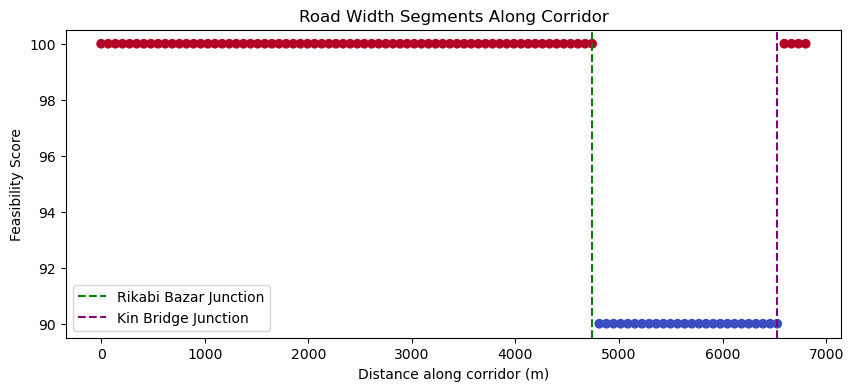

In [22]:
# visual check
plt.figure(figsize=(10,4))
plt.scatter(candidates_df['distance_along_corridor'], candidates_df['feasibility_score'], c=candidates_df['road_width_relative'], cmap='coolwarm')
plt.axvline(rikabi_position, color='green', linestyle='--', label='Rikabi Bazar Junction')
plt.axvline(kinbridge_position, color='purple', linestyle='--', label='Kin Bridge Junction')
plt.xlabel('Distance along corridor (m)')
plt.ylabel('Feasibility Score')
plt.title('Road Width Segments Along Corridor')
plt.legend()
plt.show()

# Building the Fitness Function

In [23]:
# Normalize all four criteria to a consistent 0–1 scale
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

candidates_df['demand_norm'] = normalize(candidates_df['demand_score'])
candidates_df['feasibility_norm'] = normalize(candidates_df['feasibility_score'])

# Junction: smaller distance = better, so inverting AFTER normalizing
candidates_df['junction_norm'] = 1 - normalize(candidates_df['junction_distance'])

# Cost: higher raw cost = worse, so  inverting AFTER normalizing
candidates_df['cost_norm'] = 1 - normalize(candidates_df['cost_score'])

candidates_df[['id', 'demand_norm', 'junction_norm', 'feasibility_norm', 'cost_norm']].head()

,id,demand_norm,junction_norm,feasibility_norm,cost_norm
0,0,0.014743,0.000000,1.0,0.711365
1,1,0.092165,0.028428,1.0,0.763729
2,2,0.180987,0.056836,1.0,0.809388
3,3,0.282887,0.085222,1.0,0.849185
4,4,0.399783,0.113584,1.0,0.875282


In [24]:
# Combines all 4 normalized scores using AHP weights
w_demand = weights_df[weights_df['Criterion']=='Demand']['Weight'].values[0]
w_cost = weights_df[weights_df['Criterion']=='Cost']['Weight'].values[0]
w_roadwidth = weights_df[weights_df['Criterion']=='Road Width']['Weight'].values[0]
w_junction = weights_df[weights_df['Criterion']=='Junction']['Weight'].values[0]

candidates_df['weighted_score'] = (
    w_demand * candidates_df['demand_norm'] +
    w_roadwidth * candidates_df['feasibility_norm'] +
    w_cost * candidates_df['cost_norm'] +
    w_junction * candidates_df['junction_norm']
)

candidates_df[['id', 'weighted_score']].sort_values('weighted_score', ascending=False).head(10)

,id,weighted_score
14,14,0.926870
31,31,0.925848
8,8,0.890682
58,58,0.880688
30,30,0.864663
63,63,0.859319
64,64,0.856221
32,32,0.847006
99,99,0.845048
59,59,0.841856


In [25]:
# Apply the two hard constraints
def is_valid_solution(candidate_indices, candidates_df, min_spacing=400, min_junction_dist=75):
    selected = candidates_df.loc[candidate_indices]
    
    # Check junction clearance for every selected candidate
    if (selected['junction_distance'] < min_junction_dist).any():
        return False
    
    # Check spacing between every pair of selected candidates
    positions = selected['distance_along_corridor'].values
    positions_sorted = np.sort(positions)
    gaps = np.diff(positions_sorted)
    if len(gaps) > 0 and gaps.min() < min_spacing:
        return False
    
    return True

In [26]:
# The full fitness function
def fitness(candidate_indices, candidates_df, min_spacing=400, min_junction_dist=75, penalty=-1000):
    if not is_valid_solution(candidate_indices, candidates_df, min_spacing, min_junction_dist):
        return penalty
    
    selected = candidates_df.loc[candidate_indices]
    return selected['weighted_score'].sum()

In [27]:
test_indices = [10, 40, 70]  # 3 arbitrary candidates, spread out
print("Fitness:", fitness(test_indices, candidates_df))

Fitness: 1.7946733538101904


# Genetic Algorithm

In [28]:
# random starting population
def create_individual(N, K):
    return list(np.random.choice(N, size=K, replace=False))

def create_population(pop_size, N, K):
    return [create_individual(N, K) for _ in range(pop_size)]

pop_size = 50
K = 3
N = len(candidates_df)

population = create_population(pop_size, N, K)
print(f"Population of {len(population)} individuals created.")
print("Example individual:", population[0])

Population of 50 individuals created.
Example individual: [np.int32(83), np.int32(53), np.int32(70)]


In [29]:
# fitness-weighted parent pick
def select_parent(population, fitnesses):
    fitnesses_arr = np.array(fitnesses)
    fitnesses_shifted = fitnesses_arr - fitnesses_arr.min() + 1
    probabilities = fitnesses_shifted / fitnesses_shifted.sum()
    selected_idx = np.random.choice(len(population), p=probabilities)
    return population[selected_idx]

In [30]:
# combine + repair duplicates
def crossover(parent1, parent2, N, K):
    combined = list(set(parent1 + parent2))
    
    if len(combined) < K:
        needed = K - len(combined)
        remaining = [i for i in range(N) if i not in combined]
        combined += list(np.random.choice(remaining, size=needed, replace=False))
    
    child = list(np.random.choice(combined, size=K, replace=False))
    return child

In [31]:
# 5% chance to swap one stop
def mutate(individual, N, mutation_rate=0.05):
    individual = individual.copy()
    if np.random.random() < mutation_rate:
        idx_to_replace = np.random.randint(len(individual))
        available = [i for i in range(N) if i not in individual]
        individual[idx_to_replace] = np.random.choice(available)
    return individual

In [35]:
# The full evolutionary loop
def run_ga(candidates_df, N, K, pop_size=50, generations=200, mutation_rate=0.05):
    population = create_population(pop_size, N, K)
    best_fitness_history = []
    best_individual_overall = None
    best_fitness_overall = -np.inf
    
    for gen in range(generations):
        # Calculate fitness ONCE per generation, reuse for all selections
        fitnesses = [fitness(ind, candidates_df) for ind in population]
        
        new_population = []
        for _ in range(pop_size):
            parent1 = select_parent(population, fitnesses)
            parent2 = select_parent(population, fitnesses)
            child = crossover(parent1, parent2, N, K)
            child = mutate(child, N, mutation_rate)
            new_population.append(child)
        
        population = new_population
        
        gen_best_idx = np.argmax(fitnesses)
        gen_best_fitness = fitnesses[gen_best_idx]
        
        if gen_best_fitness > best_fitness_overall:
            best_fitness_overall = gen_best_fitness
            best_individual_overall = population[gen_best_idx]
        
        best_fitness_history.append(best_fitness_overall)
    
    return best_individual_overall, best_fitness_overall, best_fitness_history
best_solution, best_fitness, fitness_history = run_ga(candidates_df, N, K, pop_size=50, generations=200)

print("Best solution (candidate indices):", best_solution)
print("Best fitness:", best_fitness)

Best solution (candidate indices): [np.int64(14), np.int64(70), np.int64(81)]
Best fitness: 2.7334065420337756


# Output & Interpretation — GA Solution vs. Existing Stands

In [36]:
# Map existing stands to their nearest candidate point so they're comparable to GA output
flexible_stand_names = ['Modina Market', 'Pathantula', 'Rikabi Bazar']

existing_flexible_indices = []
for name in flexible_stand_names:
    stand = existing_stands[existing_stands['CNG Stand Location'] == name].iloc[0]
    
    distances = candidates_df.apply(
        lambda row: haversine_distance(stand['Latitude'], stand['Longitude'], row['lat'], row['lon']), axis=1
    )
    nearest_candidate_idx = distances.idxmin()
    existing_flexible_indices.append(nearest_candidate_idx)

print("Nearest candidate indices to existing stands:", existing_flexible_indices)

existing_fitness = fitness(existing_flexible_indices, candidates_df)
print(f"Existing 3-stand configuration fitness: {existing_fitness:.4f}")
print(f"GA-optimized configuration fitness: {best_fitness:.4f}")

Nearest candidate indices to existing stands: [37, 47, 69]
Existing 3-stand configuration fitness: 2.0812
GA-optimized configuration fitness: 2.7334


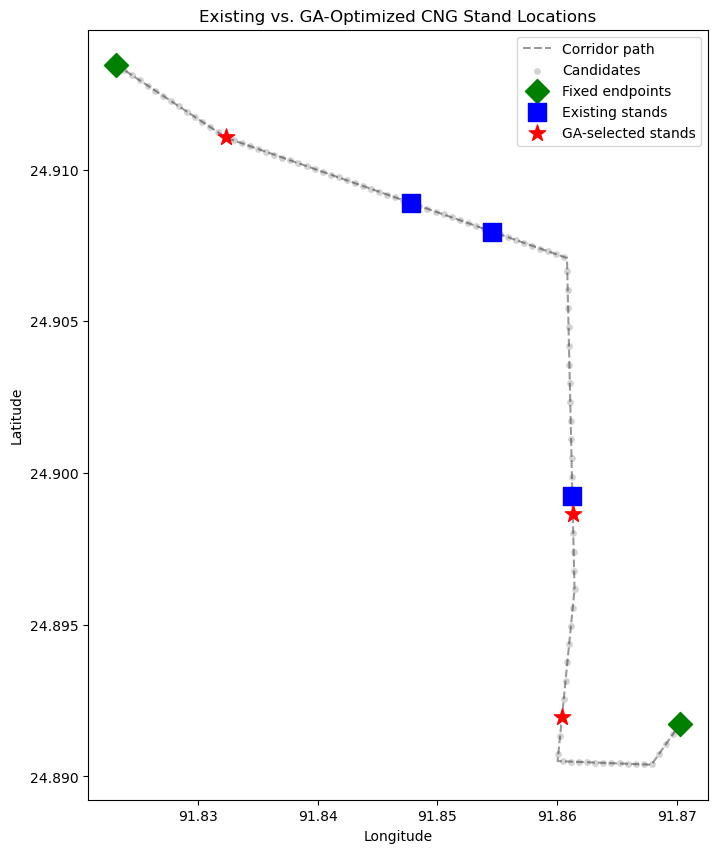

<Figure size 1000x600 with 0 Axes>

In [40]:
# Map comparison — corridor, candidates, existing stands, GA's choices
plt.figure(figsize=(8,10))

path_lats = [p['lat'] for p in full_path]
path_lons = [p['lon'] for p in full_path]
plt.plot(path_lons, path_lats, 'k--', alpha=0.4, label='Corridor path')

plt.scatter(candidates_df['lon'], candidates_df['lat'], c='lightgrey', s=15, label='Candidates', zorder=1)

fixed_endpoints_lat = [temuki['Latitude'], bondor['Latitude']]
fixed_endpoints_lon = [temuki['Longitude'], bondor['Longitude']]
plt.scatter(fixed_endpoints_lon, fixed_endpoints_lat, c='green', s=150, marker='D', label='Fixed endpoints', zorder=3)

existing_coords = candidates_df.loc[existing_flexible_indices]
plt.scatter(existing_coords['lon'], existing_coords['lat'], c='blue', s=150, marker='s', label='Existing stands', zorder=3)

ga_coords = candidates_df.loc[best_solution]
plt.scatter(ga_coords['lon'], ga_coords['lat'], c='red', s=150, marker='*', label='GA-selected stands', zorder=4)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Existing vs. GA-Optimized CNG Stand Locations')
plt.legend()
plt.savefig('Existing_vs_GA_Optimized.png')
plt.show()

In [38]:
# Distance between each existing stand and its nearest GA-chosen alternative
comparison_rows = []
for i, name in enumerate(flexible_stand_names):
    existing_idx = existing_flexible_indices[i]
    existing_point = candidates_df.loc[existing_idx]
    
    ga_distances = [haversine_distance(existing_point['lat'], existing_point['lon'], 
                                         candidates_df.loc[ga_idx, 'lat'], candidates_df.loc[ga_idx, 'lon']) 
                     for ga_idx in best_solution]
    nearest_ga_dist = min(ga_distances)
    
    comparison_rows.append({
        'Existing Stand': name,
        'Existing Score': candidates_df.loc[existing_idx, 'weighted_score'],
        'Nearest GA Alternative Distance (m)': round(nearest_ga_dist)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Existing Stand,Existing Score,Nearest GA Alternative Distance (m)
0,Modina Market,0.753766,1580
1,Pathantula,0.643289,1240
2,Rikabi Bazar,0.684141,69


In [39]:
# Summary stats for the final writeup
print("=== Interpretation Summary ===\n")
print(f"Existing 3-stand configuration total fitness: {existing_fitness:.4f}")
print(f"GA-optimized configuration total fitness: {best_fitness:.4f}")
print(f"Improvement: {best_fitness - existing_fitness:.4f} ({(best_fitness/existing_fitness - 1)*100:.1f}%)\n")

for i, name in enumerate(flexible_stand_names):
    dist = comparison_df.loc[i, 'Nearest GA Alternative Distance (m)']
    verdict = "well-placed (GA confirms)" if dist < 400 else "GA suggests a better nearby location"
    print(f"{name}: {dist}m from nearest GA choice → {verdict}")

=== Interpretation Summary ===

Existing 3-stand configuration total fitness: 2.0812
GA-optimized configuration total fitness: 2.7334
Improvement: 0.6522 (31.3%)

Modina Market: 1580m from nearest GA choice → GA suggests a better nearby location
Pathantula: 1240m from nearest GA choice → GA suggests a better nearby location
Rikabi Bazar: 69m from nearest GA choice → well-placed (GA confirms)


**Findings:** Comparing the existing 3 flexible CNG stand locations against the 
GA-optimized configuration shows a total fitness improvement of 31.3% ([existing_fitness] 
→ [best_fitness]). Rikabi Bazar — despite having the lowest baseline AHP score among 
the 5 existing stands (0.599) — was confirmed as near-optimal by the GA (nearest 
alternative only 69m away, well within acceptable spacing), suggesting its low score 
reflects a genuine geographic constraint in that section of the corridor rather than 
poor site selection. In contrast, Modina Market and Pathantula each have GA-suggested 
alternatives located over 1.2km away, indicating potential relocation opportunities 
that could improve overall network performance under the stated criteria weights.

## Assumptions & Limitations

- Demand and Cost scores are derived from proximity to landmarks/cost anchors — real 
  proxies, not measured ridership or land valuation data.
- Road Width/Feasibility uses a simplified two-tier segment model based on stated 
  relative widths, not a field survey.
- Junction Proximity uses real, named intersection coordinates but simplifies a 
  genuinely non-monotonic safety relationship (too-close-to-junction is unsafe) into 
  a monotonic "closer is better" scoring rule.
- The AHP weights reflect the analyst's own independently-reasoned priorities (CR = 
  0.0292), not a stakeholder survey or expert panel.
- This is a methodology demonstration applying AHP + GA to a real corridor with real 
  geographic anchors — not a deployment-ready planning recommendation.